In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
print("Loading datasets...")

race_df = pd.read_csv('data/processed/race_results_2025-6_clean.csv')
reddit_df = pd.read_csv('data/raw/reddit_posts.csv')
youtube_df = pd.read_csv('data/raw/youtube_videos_sponsor_2025-6.csv')
news_df = pd.read_csv('data/raw/news_mentions_2025-6_raw.csv')

print(f"Race Results: {len(race_df)} rows")
print(f"Reddit Mentions: {len(reddit_df)} rows")
print(f"YouTube Engagement: {len(youtube_df)} rows")
print(f"News Mentions: {len(news_df)} rows")

Loading datasets...
Race Results: 2013 rows
Reddit Mentions: 2468 rows
YouTube Engagement: 2406 rows
News Mentions: 57 rows


In [2]:
def audit_dataset(df, name):
    """
    Print comprehensive audit of dataset structure.
    """
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumn Names and Types:")
    print("-" * 40)
    for col in df.columns:
        dtype = df[col].dtype
        sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A"
        print(f"  {col:25} | {str(dtype):10} | Sample: {str(sample)[:30]}")
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("  None")
    return None

# Audit each dataset
audit_dataset(race_df, "Race Results")
audit_dataset(reddit_df, "Reddit Mentions")
audit_dataset(youtube_df, "YouTube Engagement")
audit_dataset(news_df, "News Mentions")


DATASET: Race Results
Shape: 2013 rows x 33 columns

Column Names and Types:
----------------------------------------
  year                      | int64      | Sample: 2025
  race_number               | int64      | Sample: 1
  race_name                 | str        | Sample: 2025 Daytona 500
  Race_Date                 | str        | Sample: 2025-02-16
  track                     | str        | Sample: Daytona International Speedway
  track_type                | str        | Sample: road course
  track_miles               | float64    | Sample: 2.4
  total_laps                | float64    | Sample: 95.0
  caution_flags             | int64      | Sample: 8
  caution_laps              | int64      | Sample: 47
  lead_changes              | int64      | Sample: 56
  avg_speed_mph             | float64    | Sample: 129.159
  pole_speed_mph            | float64    | Sample: 182.745
  margin_of_victory         | str        | Sample: .113 sec
  attendance                | float64    | Samp

In [3]:
# Define standard date format
DATE_FORMAT = '%Y-%m-%d'  # ISO 8601: 2024-02-18

def standardize_dates(df, date_columns, parse_format=None):
    """
    Convert all date columns to standard format.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame to standardize
    date_columns : list
        List of column names containing dates
    parse_format : str, optional
        Explicit format to use when parsing the input column (e.g. '%Y%m%d%H%M%S').
        Needed for numeric-looking date columns like 'seendate', since pandas
        otherwise treats an int64 column as nanoseconds since epoch instead of
        parsing it as a date string.

    Returns:
    --------
    pd.DataFrame : DataFrame with standardized dates
    """
    df = df.copy()

    for col in date_columns:
        if col not in df.columns:
            print(f"  Warning: Column '{col}' not found")
            continue

        # Convert to datetime
        if parse_format:
            df[col] = pd.to_datetime(df[col].astype(str), format=parse_format, errors='coerce')
        else:
            df[col] = pd.to_datetime(df[col], errors='coerce')

        # Check for conversion failures
        failed = df[col].isna().sum()
        if failed > 0:
            print(f"  Warning: {failed} dates failed to convert in '{col}'")

        # Convert to standard string format for CSV compatibility
        df[f'{col}_str'] = df[col].dt.strftime(DATE_FORMAT)

    return df

# Apply to each dataset
print("Standardizing dates...")

race_df = standardize_dates(race_df, ['Race_Date'])
reddit_df = standardize_dates(reddit_df, ['race_date'] if 'race_date' in reddit_df.columns else [])
youtube_df = standardize_dates(youtube_df, ['race_date'])

news_df = standardize_dates(news_df, ['seendate'], parse_format='%Y%m%d%H%M%S')

print("Date standardization complete.")

Standardizing dates...
Date standardization complete.


In [4]:
def standardize_columns(df, column_mapping):
    """
    Rename columns to standard names and convert to lowercase with underscores.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame to standardize
    column_mapping : dict
        Dictionary mapping old names to new names

    Returns:
    --------
    pd.DataFrame : DataFrame with standardized column names
    """
    df = df.copy()

    # Apply explicit mappings
    df = df.rename(columns=column_mapping)

    # Convert remaining columns to lowercase with underscores
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    return df

# Define standard column names for each dataset
race_columns = {
    'Race_Name': 'race_name',
    'Race_Date': 'race_date',
    'Race_Number': 'race_number',
    'Driver': 'driver',
    'Team': 'team',
    'Sponsor': 'sponsor',
    'Finish_Position': 'finish_position',
    'Laps_Led': 'laps_led'
}

exposure_columns = {
    'race_period': 'race_name',  # If Reddit uses race_period
    'Race_Name': 'race_name',
    'Race_Number': 'race_number',
    'Sponsor': 'sponsor'
}

# Apply standardization
race_df = standardize_columns(race_df, race_columns)
reddit_df = standardize_columns(reddit_df, exposure_columns)
youtube_df = standardize_columns(youtube_df, exposure_columns)
news_df = standardize_columns(news_df, exposure_columns)

print("Column name standardization complete.")

Column name standardization complete.


In [5]:

race_series = (
    race_df[['race_number', 'race_date']]
    .drop_duplicates()
    .assign(race_date=lambda d: pd.to_datetime(d['race_date']))
    .set_index('race_date')['race_number']
    .sort_index()
)

def assign_race_number(df, date_col='published')-> pd.DataFrame:
    """Assign race numbers based on the most recent race date on or before the given date column."""
    df = df.copy()
    normalized = pd.to_datetime(df[date_col], utc=True).dt.tz_localize(None).dt.normalize()
    df['race_number'] = normalized.apply(lambda d: race_series.asof(d))

    n_dropped = df['race_number'].isna().sum()
    if n_dropped:
        print(f"  Dropping {n_dropped} rows dated before the season opener (no matching race)")
    df = df.dropna(subset=['race_number'])
    df['race_number'] = df['race_number'].astype(int)
    return df
reddit_df = assign_race_number(reddit_df, 'published')
news_df = assign_race_number(news_df, 'seendate')

  Dropping 82 rows dated before the season opener (no matching race)
  Dropping 4 rows dated before the season opener (no matching race)


In [6]:
race_num_to_name = (race_df[['race_number', 'race_name']].drop_duplicates().set_index('race_number')['race_name']).to_dict()

def assign_race_name(df, race_num_col='race_number')-> pd.DataFrame:
    """Assign race names based on race numbers."""
    df = df.copy()
    df['race_name'] = df[race_num_col].map(race_num_to_name)
    return df

reddit_df = assign_race_name(reddit_df, 'race_number')
news_df = assign_race_name(news_df, 'race_number')
youtube_df = assign_race_name(youtube_df, 'race_number')

In [7]:
def create_race_name_mapping(df, race_col='race_name'):
    """
    Create a standardized mapping for race names.
    Returns dict mapping original names to standardized names.
    """
    unique_races = df[race_col].dropna().unique()
    print(f"Found {len(unique_races)} unique race names:")
    for race in sorted(unique_races):
        print(f"  - {race}")
    n_missing = df[race_col].isna().sum()
    if n_missing:
        print(f"  ({n_missing} rows with no matching race — dated before/after the season)")
    return unique_races

# Check race names in each dataset
print("\n=== Race Names in Race Results ===")
race_names_main = create_race_name_mapping(race_df)

print("\n=== Race Names in Reddit Data ===")
race_names_reddit = create_race_name_mapping(reddit_df)

print("\n=== Race Names in YouTube Data ===")
race_names_youtube = create_race_name_mapping(youtube_df)

print("\n=== Race Names in News Data ===")
race_names_news = create_race_name_mapping(news_df)


=== Race Names in Race Results ===
Found 52 unique race names:
  - 2025 AdventHealth 400
  - 2025 Ambetter Health 400
  - 2025 Autotrader EchoPark Automotive 400
  - 2025 Bank of America ROVAL 400
  - 2025 Bass Pro Shops Night Race
  - 2025 Brickyard 400 Presented by PPG
  - 2025 Coca-Cola 600
  - 2025 Coke Zero Sugar 400
  - 2025 Cook Out 400
  - 2025 Cracker Barrel 400
  - 2025 Cup Series Championship
  - 2025 Daytona 500
  - 2025 EchoPark Automotive Grand Prix
  - 2025 Enjoy Illinois 300
  - 2025 Firekeepers Casino 400
  - 2025 Food City 500
  - 2025 Go Bowling at The Glen
  - 2025 Goodyear 400
  - 2025 Grant Park 165
  - 2025 Hollywood Casino 400
  - 2025 Iowa Corn 350
  - 2025 Jack Links 500
  - 2025 Mobil 1 301
  - 2025 Pennzoil 400
  - 2025 Quaker State 400 available at Walmart
  - 2025 Shriners Childrens 500
  - 2025 South Point 400
  - 2025 Southern 500
  - 2025 Straight Talk Wireless 400
  - 2025 The Great American Getaway 400
  - 2025 Toyota / Save Mart 350
  - 2025 Viva Me

In [8]:
# Create master race name mapping
# This ensures all datasets use exactly the same race names

RACE_NAME_MAPPING = {
    
    '2025 Daytona 500': '2025 Daytona 500',
    '2025 DAYTONA 500': '2025 Daytona 500',
    '2025 Ambetter Health 400': '2025 Ambetter Health 400',
    '2025 Ambetter 400': '2025 Ambetter Health 400',
    '2025 Pennzoil 400': '2025 Pennzoil 400',
    '2025 Pennzoil 400 Las Vegas': '2025 Pennzoil 400',
    '2025 Wurth 400 presented by LIQUI MOLLY': '2025 Wurth 400',
    '2025 Quaker State 400 available at Walmart': '2025 Quaker State 400',
    '2025 Toyota / Save Mart 350': '2025 Toyota Save Mart 350',
    '2025 Brickyard 400 Presented by PPG': '2025 Brickyard 400',
    '2026 Autotrader 400 at EchoPark Speedway': '2026 Autotrader 400',
    '2026 DuraMax Texas Grand Prix Presented by RelaDyne': '2026 DuraMax Texas Grand Prix',
    '2026 Pennzoil 400 Presented by Jiffy Lube': '2026 Pennzoil 400',
    '2026 Wurth 400 Presented by LIQUI MOLY': '2026 Wurth 400',
    
}

def standardize_race_names(df, mapping, race_col='race_name'):
    """
    Apply race name standardization.
    """
    df = df.copy()

    # Apply mapping where available
    df[race_col] = df[race_col].replace(mapping)

    # Check for unmapped races
    unmapped = df[~df[race_col].isin(mapping.values())][race_col].unique()
    if len(unmapped) > 0:
        print(f"Warning: {len(unmapped)} race names not in mapping:")
        for name in unmapped:
            print(f"  - '{name}'")

    return df

# Apply to all datasets
race_df = standardize_race_names(race_df, RACE_NAME_MAPPING)
reddit_df = standardize_race_names(reddit_df, RACE_NAME_MAPPING)
youtube_df = standardize_race_names(youtube_df, RACE_NAME_MAPPING)
news_df = standardize_race_names(news_df, RACE_NAME_MAPPING)

  - '2025 EchoPark Automotive Grand Prix'
  - '2025 Shriners Childrens 500'
  - '2025 Straight Talk Wireless 400'
  - '2025 Cook Out 400'
  - '2025 Goodyear 400'
  - '2025 Food City 500'
  - '2025 Jack Links 500'
  - '2025 Wurth 400 Presented by LIQUI MOLY'
  - '2025 AdventHealth 400'
  - '2025 Coca-Cola 600'
  - '2025 Cracker Barrel 400'
  - '2025 Firekeepers Casino 400'
  - '2025 Viva Mexico 250'
  - '2025 The Great American Getaway 400'
  - '2025 Grant Park 165'
  - '2025 Autotrader EchoPark Automotive 400'
  - '2025 Iowa Corn 350'
  - '2025 Go Bowling at The Glen'
  - '2025 Coke Zero Sugar 400'
  - '2025 Southern 500'
  - '2025 Enjoy Illinois 300'
  - '2025 Bass Pro Shops Night Race'
  - '2025 Mobil 1 301'
  - '2025 Hollywood Casino 400'
  - '2025 Bank of America ROVAL 400'
  - '2025 South Point 400'
  - '2025 Yellawood 500'
  - '2025 Xfinity 500'
  - '2025 Cup Series Championship'
  - '2026 Daytona 500'
  - '2026 Straight Talk Wireless 500'
  - '2026 Goodyear 400'
  - '2026 Cook O

In [9]:
# Sponsor name standardization
SPONSOR_NAME_MAPPING = {
    'FedEx': 'FedEx',
    'Fedex': 'FedEx',
    'FEDEX': 'FedEx',
    'NAPA': 'NAPA',
    'NAPA Auto Parts': 'NAPA',
    'Napa': 'NAPA',
    "McDonald's": "McDonald's",
    'McDonalds': "McDonald's",
    "Mcdonald's": "McDonald's",
    'Ally': 'Ally',
    'Ally Financial': 'Ally',
    'Ally Racing': 'Ally',
    'Busch Light': 'Busch Light',
    'Busch': 'Busch Light',
    'Busch Light Apple': 'Busch Light',
    'progressive': 'Progressive',
    'Progressive Insurance': 'Progressive',
    'progressive insurance': 'Progressive',
    'Progressive insurance': 'Progressive',
    'castrol': 'Castrol',
    'Love\'s Travel Stops': 'Love\'s Travel Stops',
    'Loves Travel Stops': 'Love\'s Travel Stops',
    'love\'s travel stops': 'Love\'s Travel Stops',
    'Love\'s': 'Love\'s Travel Stops',
    'Love’s Travel Stops': 'Love\'s Travel Stops',
    'love’s travel stops': 'Love\'s Travel Stops',
    'Love’s': 'Love\'s Travel Stops',
    'love’s': 'Love\'s Travel Stops',
    'Cheddar\'s Scratch Kitchen': 'Cheddar\'s Scratch Kitchen',
    'Cheddar’s Scratch Kitchen': 'Cheddar\'s Scratch Kitchen',
    'Cheddar’s': 'Cheddar\'s Scratch Kitchen',
    'Cheddar\'s': 'Cheddar\'s Scratch Kitchen',
    'cheddar’s': 'Cheddar\'s Scratch Kitchen',
    'cheddar\'s': 'Cheddar\'s Scratch Kitchen',
    'cheddar’s scratch kitchen': 'Cheddar\'s Scratch Kitchen',
    'cheddar\'s scratch kitchen': 'Cheddar\'s Scratch Kitchen',
}

def standardize_sponsor_names(df, mapping, sponsor_col='sponsor'):
    """
    Apply sponsor name standardization.
    """
    df = df.copy()
    df[sponsor_col] = df[sponsor_col].replace(mapping)

    # Verify all sponsors are standardized
    target_sponsors = ['Progressive', 'Castrol', 'Cheddar\'s Scratch Kitchen', 'Love\'s Travel Stops', 'Busch Light']
    unique_sponsors = df[sponsor_col].unique()
    unexpected = [s for s in unique_sponsors if s not in target_sponsors]
    if unexpected:
        print(f"Warning: Unexpected sponsors found: {unexpected}")

    return df

# Apply to all datasets
reddit_df = standardize_sponsor_names(reddit_df, SPONSOR_NAME_MAPPING)
news_df = standardize_sponsor_names(news_df, SPONSOR_NAME_MAPPING)


In [10]:
def consolidate_sponsor_mentions(df, sponsor_names, prefix='features_', new_col='sponsor'):
    """
    Collapse the per-sponsor boolean mention columns (e.g. 'features_progressive',
    'features_castrol') into a single column holding the sponsor name(s) mentioned
    in that row.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing one boolean column per sponsor
    sponsor_names : list
        Canonical sponsor names (e.g. from SPONSOR_NAME_MAPPING), used to recover
        proper casing/punctuation lost when column names were lowercased
    prefix : str
        Prefix shared by all the mention columns
    new_col : str
        Name of the resulting sponsor column

    Returns:
    --------
    pd.DataFrame : DataFrame with the mention columns replaced by `new_col`
    """
    df = df.copy()

    mention_cols = [c for c in df.columns if c.startswith(prefix)]
    if not mention_cols:
        print(f"Warning: no columns found with prefix '{prefix}'")
        return df

    # Map each column's normalized suffix back to its canonical sponsor name
    normalized_to_canonical = {name.lower().replace(' ', '_'): name for name in sponsor_names}
    col_to_sponsor = {col: normalized_to_canonical.get(col[len(prefix):], col[len(prefix):]) for col in mention_cols}

    def sponsors_in_row(row):
        mentioned = [col_to_sponsor[c] for c in mention_cols if row[c]]
        return ', '.join(mentioned) if mentioned else None

    df[new_col] = df[mention_cols].apply(sponsors_in_row, axis=1)
    df = df.drop(columns=mention_cols)

    return df

# Collapse features_* columns into a single 'sponsor' column
youtube_df = consolidate_sponsor_mentions(youtube_df, sponsor_names=list(SPONSOR_NAME_MAPPING.values()))
print("Sponsors found in YouTube data:")
print(youtube_df['sponsor'].value_counts(dropna=False))

Sponsors found in YouTube data:
sponsor
NaN                                       1507
Progressive                                251
Love's Travel Stops                        229
Busch Light                                198
Cheddar's Scratch Kitchen                  138
Castrol                                     71
Progressive, Cheddar's Scratch Kitchen       9
Progressive, Busch Light                     2
Progressive, Love's Travel Stops             1
Name: count, dtype: int64


In [11]:
def create_merge_key(df, components=['race_number', 'sponsor']):
    """
    Create a unique merge key from multiple columns.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame to add merge key to
    components : list
        Columns to combine into merge key

    Returns:
    --------
    pd.DataFrame : DataFrame with merge_key column added
    """
    df = df.copy()

    # Ensure components exist
    missing = [c for c in components if c not in df.columns]
    if missing:
        print(f"Warning: Columns missing for merge key: {missing}")
        return df

    # Create merge key
    df['merge_key'] = df[components].fillna('unknown').astype(str).agg('_'.join, axis=1)

    return df

# Add merge keys to all datasets
race_agg = race_df.groupby(['race_number', 'primary_sponsor']).first().reset_index()
race_agg = create_merge_key(race_agg, components=['race_number', 'primary_sponsor'])

reddit_df = create_merge_key(reddit_df)
youtube_df = create_merge_key(youtube_df)
news_df = create_merge_key(news_df)

print("Sample merge keys:")
print(race_agg['merge_key'].head(15).tolist())

Sample merge keys:
['1_Busch Light', "1_Love's Travel Stops", '1_Other/Unknown', "2_Cheddar's Scratch Kitchen", '2_Other/Unknown', '3_Busch Light', '3_Castrol', "3_Love's Travel Stops", '3_Other/Unknown', '4_Other/Unknown', '5_Castrol', "5_Love's Travel Stops", '5_Other/Unknown', "6_Love's Travel Stops", '6_Other/Unknown']


In [12]:
# Save standardized versions
race_df.to_csv('data/processed/race_results_standardized.csv', index=False)
reddit_df.to_csv('data/processed/reddit_mentions_standardized.csv', index=False)
youtube_df.to_csv('data/processed/youtube_engagement_standardized.csv', index=False)
news_df.to_csv('data/processed/news_mentions_standardized.csv', index=False)

print("Standardized datasets saved.")

# Document the standardization rules
standardization_log = {
    'date_format': DATE_FORMAT,
    'race_name_mapping_count': len(RACE_NAME_MAPPING),
    'sponsor_name_mapping_count': len(SPONSOR_NAME_MAPPING),
    'merge_key_components': ['race_number', 'sponsor'],
    'standardization_date': datetime.now().isoformat()
}

import json
with open('data/processed/standardization_log.json', 'w') as f:
    json.dump(standardization_log, f, indent=2)

print("Standardization log saved.")

Standardized datasets saved.
Standardization log saved.


In [13]:
# Load standardized data
race_df = pd.read_csv('data/processed/race_results_standardized.csv')
reddit_df = pd.read_csv('data/processed/reddit_mentions_standardized.csv')
youtube_df = pd.read_csv('data/processed/youtube_engagement_standardized.csv')
news_df = pd.read_csv('data/processed/news_mentions_standardized.csv')

# Create race-level summary from race results
# (Each row = one sponsor at one race)
race_base = race_df.groupby(['race_number', 'race_name', 'race_date', 'primary_sponsor']).agg({
    'finish_position': 'min',  # Best finish among cars carrying that sponsor
    'laps_led': 'sum'  # Total laps led by cars carrying that sponsor
}).reset_index()

# Add merge key
race_base['merge_key'] = race_base['race_number'].astype(str) + '_' + race_base['primary_sponsor']

n_races = race_df['race_number'].nunique()
n_sponsors = race_df['primary_sponsor'].nunique()
print(f"Base dataset: {len(race_base)} sponsor-race combinations")
print(f"Expected: {n_races} races x {n_sponsors} sponsors = {n_races * n_sponsors} rows")
print(f"Actual: {len(race_base)} rows")

# Check for any sponsor-race combinations
print("\nSponsor coverage:")
print(race_base.groupby('primary_sponsor').size())

Base dataset: 150 sponsor-race combinations
Expected: 53 races x 6 sponsors = 318 rows
Actual: 150 rows

Sponsor coverage:
primary_sponsor
Busch Light                  25
Castrol                      11
Cheddar's Scratch Kitchen    12
Love's Travel Stops          29
Other/Unknown                53
Progressive                  20
dtype: int64


In [14]:
# all I need is the number of reddit posts per sponsor per race, I wasnt able to get engagement data
def sum_engagement_per_race(df:pd.DataFrame)->pd.DataFrame:
    num_mentions = df[['merge_key']].value_counts()
    # merge key is sponsor and race number in one
    print(num_mentions.head(10))
    return num_mentions
reddit_mentions = sum_engagement_per_race(reddit_df)
reddit_mentions_df = reddit_mentions.reset_index()
reddit_mentions_df = reddit_mentions_df.rename(columns={'count':'reddit_mention_count'})

# Perform left join
master_df = race_base.merge(
    reddit_mentions_df,
    on='merge_key',
    how='left',
    indicator='_reddit_merge'
)

# Check merge results
print("\nReddit merge results:")
print(master_df['_reddit_merge'].value_counts())

# Count matches
matched = (master_df['_reddit_merge'] == 'both').sum()
total = len(master_df)
print(f"Match rate: {matched}/{total} ({matched/total*100:.1f}%)")

# Unmatched sponsor-races had zero reddit posts, not a missing value
master_df['reddit_mention_count'] = master_df['reddit_mention_count'].fillna(0)
master_df = master_df.drop(columns=['_reddit_merge'])

merge_key                   
48_Cheddar's Scratch Kitchen    155
36_Progressive                  142
36_Cheddar's Scratch Kitchen    118
36_Castrol                       71
36_Busch Light                   53
49_Cheddar's Scratch Kitchen     50
36_Love's Travel Stops           37
5_Progressive                    34
12_Cheddar's Scratch Kitchen     26
48_Progressive                   25
Name: count, dtype: int64

Reddit merge results:
_reddit_merge
both          97
left_only     53
right_only     0
Name: count, dtype: int64
Match rate: 97/150 (64.7%)


In [15]:
# Prepare YouTube data for merge
youtube_merge = youtube_df[['merge_key', 'view_count', 'like_count','comment_count','duration']].copy()

# duration comes from the YouTube API as an ISO 8601 duration string (e.g. 'PT5M50S'),
# so it has to be converted to seconds before it can be summed
youtube_merge['duration_seconds'] = pd.to_timedelta(youtube_merge['duration']).dt.total_seconds()

youtube_agg = youtube_merge.groupby('merge_key').agg(
    youtube_total_view_count=('view_count', 'sum'),
    youtube_total_like_count=('like_count', 'sum'),
    youtube_total_comment_count=('comment_count', 'sum'),
    youtube_total_duration_seconds=('duration_seconds', 'sum'),
    num_youtube_videos=('merge_key', 'count')
).reset_index()


# Check for duplicate merge keys
dupes = youtube_agg['merge_key'].duplicated().sum()
if dupes > 0:
    print(f"Warning: {dupes} duplicate merge keys in YouTube data")
    youtube_merge = youtube_merge.drop_duplicates(subset='merge_key', keep='first')

# Perform left join
master_df = master_df.merge(
    youtube_agg,
    on='merge_key',
    how='left',
    indicator='_youtube_merge'
)

# Check merge results
print("\nYouTube merge results:")
print(master_df['_youtube_merge'].value_counts())

matched = (master_df['_youtube_merge'] == 'both').sum()
print(f"Match rate: {matched}/{len(master_df)} ({matched/len(master_df)*100:.1f}%)")

# Handle unmatched
youtube_cols = ['youtube_total_view_count', 'num_youtube_videos',
                'youtube_total_like_count', 'youtube_total_comment_count', 'youtube_total_duration_seconds']
for col in youtube_cols:
    master_df[col] = master_df[col].fillna(0)

master_df = master_df.drop(columns=['_youtube_merge'])


YouTube merge results:
_youtube_merge
left_only     90
both          60
right_only     0
Name: count, dtype: int64
Match rate: 60/150 (40.0%)


In [16]:
# Prepare News data for merge
news_merge = news_df[['merge_key', 'mention_type',
                       'tier_weight']].copy()

news_agg = news_df.groupby('merge_key').agg(
    news_total_mentions=('merge_key','count'),
    news_weighted_mentions=('tier_weight','sum')
).reset_index()

mention_type_counts = pd.crosstab(news_df['merge_key'], news_df['mention_type']).reset_index()
mention_type_counts = mention_type_counts.rename(columns={
    'primary': 'news_primary_mentions',
    'secondary': 'news_secondary_mentions',
    'passing': 'news_passing_mentions'
})

news_agg = news_agg.merge(mention_type_counts, on='merge_key', how='left')

# Check for duplicate merge keys
dupes = news_agg['merge_key'].duplicated().sum()
if dupes > 0:
    print(f"Warning: {dupes} duplicate merge keys in News data")
    news_merge = news_merge.drop_duplicates(subset='merge_key', keep='first')

# Perform left join
master_df = master_df.merge(
    news_agg,
    on='merge_key',
    how='left',
    indicator='_news_merge'
)

# Check merge results
print("\nNews merge results:")
print(master_df['_news_merge'].value_counts())

matched = (master_df['_news_merge'] == 'both').sum()
print(f"Match rate: {matched}/{len(master_df)} ({matched/len(master_df)*100:.1f}%)")

# Handle unmatched
news_cols = ['news_total_mentions', 'news_weighted_mentions', 'news_primary_mentions','news_secondary_mentions','news_passing_mentions']
for col in news_cols:
    master_df[col] = master_df[col].fillna(0)

master_df = master_df.drop(columns=['_news_merge'])


News merge results:
_news_merge
left_only     120
both           30
right_only      0
Name: count, dtype: int64
Match rate: 30/150 (20.0%)


In [17]:
# Prepare pytrends data for merge
# Each pytrends_daily_{driver}_2025-6.csv has columns: date, <driver name>, <sponsor name>
import glob

pytrends_rows = []
for path in glob.glob('data/processed/pytrends_daily_*_2025-6.csv'):
    pt_df = pd.read_csv(path, parse_dates=['date'])
    driver_col, sponsor_col = pt_df.columns[1], pt_df.columns[2]

    sponsor_name = SPONSOR_NAME_MAPPING.get(sponsor_col, sponsor_col)

    pt_df = pt_df.rename(columns={driver_col: 'driver_search_interest', sponsor_col: 'sponsor_search_interest'})
    pt_df['race_number'] = pt_df['date'].apply(lambda d: race_series.asof(d))
    pt_df['primary_sponsor'] = sponsor_name
    pytrends_rows.append(pt_df[['race_number', 'primary_sponsor', 'driver_search_interest', 'sponsor_search_interest']])

pytrends_df = pd.concat(pytrends_rows, ignore_index=True).dropna(subset=['race_number'])
pytrends_df['race_number'] = pytrends_df['race_number'].astype(int)

# Average interest for races that fall in the same Trends week
pytrends_agg = pytrends_df.groupby(['race_number', 'primary_sponsor']).agg(
    driver_search_interest=('driver_search_interest', 'mean'),
    sponsor_search_interest=('sponsor_search_interest', 'mean')
).reset_index()

pytrends_agg = create_merge_key(pytrends_agg, components=['race_number', 'primary_sponsor'])
pytrends_agg = pytrends_agg.drop(columns=['race_number', 'primary_sponsor'])

# Perform left join
master_df = master_df.merge(
    pytrends_agg,
    on='merge_key',
    how='left',
    indicator='_pytrends_merge'
)

# Check merge results
print("\nPytrends merge results:")
print(master_df['_pytrends_merge'].value_counts())

matched = (master_df['_pytrends_merge'] == 'both').sum()
print(f"Match rate: {matched}/{len(master_df)} ({matched/len(master_df)*100:.1f}%)")

master_df = master_df.drop(columns=['_pytrends_merge'])



Pytrends merge results:
_pytrends_merge
both          85
left_only     65
right_only     0
Name: count, dtype: int64
Match rate: 85/150 (56.7%)


In [18]:
def spot_check_merge(master_df, race_number, sponsor, original_dfs):
    """
    Verify merge accuracy by recomputing each aggregate directly from the
    original per-row source data and comparing it to the merged value.

    Parameters:
    -----------
    master_df : pd.DataFrame
        Merged master dataset
    race_number : int
        Race number to check
    sponsor : str
        Sponsor name to check
    original_dfs : dict
        Dictionary of original DataFrames {'reddit': df, 'youtube': df, 'news': df}
    """
    print(f"\n{'='*60}")
    print(f"SPOT CHECK: Race {race_number} - {sponsor}")
    print(f"{'='*60}")

    # Get merged record
    merged = master_df[
        (master_df['race_number'] == race_number) &
        (master_df['primary_sponsor'] == sponsor)
    ]

    if len(merged) == 0:
        print("No matching record found in master dataset!")
        return

    merged = merged.iloc[0]
    merge_key = merged['merge_key']

    print(f"\nMerge Key: {merge_key}")
    print(f"Race Name: {merged['race_name']}")
    print(f"Finish Position: {merged['finish_position']}")

    # Check Reddit values
    print(f"\n--- Reddit Data ---")
    print(f"Master: {merged['reddit_mention_count']:.0f} mentions")

    reddit_original = original_dfs['reddit'][original_dfs['reddit']['merge_key'] == merge_key]
    original_reddit_count = len(reddit_original)
    print(f"Original: {original_reddit_count} posts found")
    print("MATCH" if merged['reddit_mention_count'] == original_reddit_count else "MISMATCH!")

    # Check YouTube values
    print(f"\n--- YouTube Data ---")
    print(f"Master: {merged['youtube_total_view_count']:,.0f} total views across {merged['num_youtube_videos']:.0f} videos")

    youtube_original = original_dfs['youtube'][original_dfs['youtube']['merge_key'] == merge_key]
    original_view_count = youtube_original['view_count'].sum()
    print(f"Original: {original_view_count:,.0f} total views across {len(youtube_original)} videos")
    print("MATCH" if merged['youtube_total_view_count'] == original_view_count else "MISMATCH!")

    # Check News values
    print(f"\n--- News Data ---")
    print(f"Master: {merged['news_total_mentions']:.0f} mentions")

    news_original = original_dfs['news'][original_dfs['news']['merge_key'] == merge_key]
    original_news_count = len(news_original)
    print(f"Original: {original_news_count} mentions found")
    print("MATCH" if merged['news_total_mentions'] == original_news_count else "MISMATCH!")

# Run spot checks on several records
original_dfs = {
    'reddit': reddit_df,
    'youtube': youtube_df,
    'news': news_df
}

# Check high-profile race
spot_check_merge(master_df, 1, 'Progressive', original_dfs)

# Check mid-season race
spot_check_merge(master_df, 18, 'Castrol', original_dfs)

# Check late-season race
spot_check_merge(master_df, 35, "Busch Light", original_dfs)


SPOT CHECK: Race 1 - Progressive
No matching record found in master dataset!

SPOT CHECK: Race 18 - Castrol
No matching record found in master dataset!

SPOT CHECK: Race 35 - Busch Light
No matching record found in master dataset!


In [19]:
print("\n" + "="*60)
print("MASTER DATASET SUMMARY")
print("="*60)

print(f"\nDataset Shape: {master_df.shape[0]} rows x {master_df.shape[1]} columns")

print(f"\nRace Coverage:")
print(f"  Total races: {master_df['race_number'].nunique()}")
print(f"  First race: {master_df['race_number'].min()} ({master_df[master_df['race_number']==master_df['race_number'].min()]['race_name'].iloc[0]})")
print(f"  Last race: {master_df['race_number'].max()} ({master_df[master_df['race_number']==master_df['race_number'].max()]['race_name'].iloc[0]})")

print(f"\nSponsor Coverage:")
for sponsor in master_df['primary_sponsor'].unique():
    count = len(master_df[master_df['primary_sponsor'] == sponsor])
    print(f"  {sponsor}: {count} race entries")

print(f"\nExposure Data Summary:")
print(f"  Reddit mentions: {master_df['reddit_mention_count'].sum():,.0f} total")
print(f"  YouTube views: {master_df['youtube_total_view_count'].sum():,.0f} total race views")
print(f"  News mentions: {master_df['news_total_mentions'].sum():,.0f} total")

print(f"\nMissing Values:")
missing = master_df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  None (all missing values filled)")


MASTER DATASET SUMMARY

Dataset Shape: 150 rows x 20 columns

Race Coverage:
  Total races: 53
  First race: 1 (2025 Daytona 500)
  Last race: 53 (2026 Anduril 250)

Sponsor Coverage:
  Busch Light: 25 race entries
  Love's Travel Stops: 29 race entries
  Other/Unknown: 53 race entries


  Cheddar's Scratch Kitchen: 12 race entries
  Castrol: 11 race entries
  Progressive: 20 race entries

Exposure Data Summary:
  Reddit mentions: 988 total
  YouTube views: 7,253,798 total race views
  News mentions: 42 total

Missing Values:
driver_search_interest     65
sponsor_search_interest    65
dtype: int64


In [20]:
# Save the merged dataset
intermediate_path = 'data/processed/master_dataset_merged.csv'
master_df.to_csv(intermediate_path, index=False)
print(f"\nMerged dataset saved to: {intermediate_path}")

# Save merge statistics
merge_stats = {
    'merge_date': datetime.now().isoformat(),
    'total_rows': len(master_df),
    'unique_races': int(master_df['race_number'].nunique()),
    'unique_sponsors': int(master_df['primary_sponsor'].nunique()),
    'reddit_match_rate': float((master_df['reddit_mention_count'] > 0).mean()),
    'youtube_match_rate': float((master_df['youtube_total_view_count'] > 0).mean()),
    'news_match_rate': float((master_df['news_total_mentions'] > 0).mean())
}

with open('data/processed/merge_statistics.json', 'w') as f:
    json.dump(merge_stats, f, indent=2)

print("Merge statistics saved.")


Merged dataset saved to: data/processed/master_dataset_merged.csv
Merge statistics saved.


In [21]:
# Load merged dataset
master_df = pd.read_csv('data/processed/master_dataset_merged.csv')

print("="*60)
print("DATA COMPLETENESS CHECK")
print("="*60)

# Expected dimensions
expected_races = 53
expected_sponsors = 5
expected_rows = expected_races * expected_sponsors

print(f"\nExpected: {expected_races} races x {expected_sponsors} sponsors = {expected_rows} rows")
print(f"Actual: {len(master_df)} rows")
print(f"Difference: {len(master_df) - expected_rows}")

# Check for missing sponsor-race combinations
print("\n--- Missing Combinations ---")
all_combinations = set()
for race_num in range(1, 37):
    for sponsor in ['Progressive', 'Cheddar\'s Scratch Kitchen', "Love\'s Travel Stops", 'Castrol', 'Busch Light']:
        all_combinations.add((race_num, sponsor))

actual_combinations = set(zip(master_df['race_number'], master_df['primary_sponsor']))
missing_combinations = all_combinations - actual_combinations

if missing_combinations:
    print(f"Missing {len(missing_combinations)} combinations:")
    for combo in sorted(missing_combinations)[:10]:
        print(f"  Race {combo[0]}: {combo[1]}")
else:
    print("All expected combinations present.")

# Check column completeness
print("\n--- Column Completeness ---")
for col in master_df.columns:
    null_count = master_df[col].isnull().sum()
    null_pct = null_count / len(master_df) * 100
    if null_count > 0:
        print(f"  {col}: {null_count} nulls ({null_pct:.1f}%)")
    else:
        print(f"  {col}: Complete")

DATA COMPLETENESS CHECK

Expected: 53 races x 5 sponsors = 265 rows
Actual: 150 rows
Difference: -115

--- Missing Combinations ---
Missing 111 combinations:
  Race 1: Castrol
  Race 1: Cheddar's Scratch Kitchen
  Race 1: Progressive
  Race 2: Busch Light
  Race 2: Castrol
  Race 2: Love's Travel Stops
  Race 2: Progressive
  Race 3: Cheddar's Scratch Kitchen
  Race 3: Progressive
  Race 4: Busch Light

--- Column Completeness ---
  race_number: Complete
  race_name: Complete
  race_date: Complete
  primary_sponsor: Complete
  finish_position: Complete
  laps_led: Complete
  merge_key: Complete
  reddit_mention_count: Complete
  youtube_total_view_count: Complete
  youtube_total_like_count: Complete
  youtube_total_comment_count: Complete
  youtube_total_duration_seconds: Complete
  num_youtube_videos: Complete
  news_total_mentions: Complete
  news_weighted_mentions: Complete
  news_passing_mentions: Complete
  news_primary_mentions: Complete
  news_secondary_mentions: Complete
  driv

In [22]:
print("\n" + "="*60)
print("DATA CONSISTENCY CHECK")
print("="*60)

# Check 1: Finish position should be between 1 and ~40
print("\n--- Finish Position Range ---")
min_pos = master_df['finish_position'].min()
max_pos = master_df['finish_position'].max()
print(f"Range: {min_pos} to {max_pos}")

invalid_positions = master_df[
    (master_df['finish_position'] < 1) |
    (master_df['finish_position'] > 45)  # Allow for large fields
]
if len(invalid_positions) > 0:
    print(f"WARNING: {len(invalid_positions)} records with invalid finish positions")
    print(invalid_positions[['race_name', 'primary_sponsor', 'finish_position']])
else:
    print("All finish positions valid")

# Check 2: Laps led should be non-negative
print("\n--- Laps Led Range ---")
negative_laps = master_df[master_df['laps_led'] < 0]
if len(negative_laps) > 0:
    print(f"WARNING: {len(negative_laps)} records with negative laps led")
else:
    print("All laps led values non-negative")
    print(f"Range: {master_df['laps_led'].min()} to {master_df['laps_led'].max()}")



# Check 4: Dates should be in 2025-6 season
print("\n--- Date Range ---")
master_df['race_date'] = pd.to_datetime(master_df['race_date'])
min_date = master_df['race_date'].min()
max_date = master_df['race_date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

season_start = pd.Timestamp('2025-02-01')
season_end = pd.Timestamp('2026-11-30')
out_of_range = master_df[
    (master_df['race_date'] < season_start) |
    (master_df['race_date'] > season_end)
]
if len(out_of_range) > 0:
    print(f"WARNING: {len(out_of_range)} records outside expected date range")
else:
    print("All dates within expected 2024 season range")


DATA CONSISTENCY CHECK

--- Finish Position Range ---
Range: 1 to 40
All finish positions valid

--- Laps Led Range ---
All laps led values non-negative
Range: 0 to 505

--- Date Range ---
Date range: 2025-02-16 to 2026-06-21
All dates within expected 2024 season range


In [23]:
print("\n" + "="*60)
print("OUTLIER DETECTION")
print("="*60)

def detect_outliers(df, column, threshold=3):
    """
    Detect outliers using z-score method.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame to check
    column : str
        Column to analyze
    threshold : float
        Z-score threshold for outlier detection

    Returns:
    --------
    pd.DataFrame : Rows identified as outliers
    """
    mean = df[column].mean()
    std = df[column].std()

    if std == 0:
        return pd.DataFrame()

    z_scores = (df[column] - mean) / std
    outliers = df[abs(z_scores) > threshold].copy()
    outliers['z_score'] = z_scores[abs(z_scores) > threshold]

    return outliers

# Check key metrics for outliers
metrics_to_check = [
    'reddit_mention_count',
    
    'youtube_total_view_count',
  
    'news_total_mentions'
]

outlier_summary = {}

for metric in metrics_to_check:
    print(f"\n--- {metric} ---")
    outliers = detect_outliers(master_df, metric)

    if len(outliers) > 0:
        print(f"Found {len(outliers)} outliers (z-score > 3):")
        print(outliers[['race_name', 'primary_sponsor', metric, 'z_score']].to_string())
        outlier_summary[metric] = len(outliers)
    else:
        print("No statistical outliers detected")
        outlier_summary[metric] = 0

# Investigate specific outliers
print("\n" + "="*60)
print("OUTLIER INVESTIGATION")
print("="*60)

# High Reddit mentions - likely wins or controversies
high_reddit = master_df.nlargest(5, 'reddit_mention_count')
print("\nTop 5 Reddit Mentions:")
print(high_reddit[['race_name', 'primary_sponsor', 'finish_position', 'reddit_mention_count']])

# High YouTube views - major races
high_youtube = master_df.nlargest(5, 'youtube_total_view_count')
print("\nTop 5 YouTube Views:")
print(high_youtube[['race_name', 'primary_sponsor', 'youtube_total_view_count']])

# later I will do a more rigorous test using shapiro wilks and qq plots


OUTLIER DETECTION

--- reddit_mention_count ---
Found 3 outliers (z-score > 3):
                        race_name            primary_sponsor  reddit_mention_count   z_score
100  2025 Cup Series Championship                    Castrol                  71.0  3.838483
101  2025 Cup Series Championship  Cheddar's Scratch Kitchen                 118.0  6.639280
104  2025 Cup Series Championship                Progressive                 142.0  8.069474

--- youtube_total_view_count ---
Found 2 outliers (z-score > 3):
                        race_name            primary_sponsor  youtube_total_view_count   z_score
95             2025 Yellawood 500  Cheddar's Scratch Kitchen                  500092.0  4.741229
101  2025 Cup Series Championship  Cheddar's Scratch Kitchen                  517351.0  4.922373

--- news_total_mentions ---
Found 2 outliers (z-score > 3):
                  race_name primary_sponsor  news_total_mentions   z_score
33    2025 AdventHealth 400     Busch Light           

In [24]:
print("\n" + "="*60)
print("CROSS-SOURCE VALIDATION")
print("="*60)

# Check: Wins should have higher average exposure than non-wins
wins = master_df[master_df['finish_position'] == 1]
non_wins = master_df[master_df['finish_position'] > 1]

print("\n--- Win vs Non-Win Exposure ---")
print(f"{'Metric':<30} {'Wins':>15} {'Non-Wins':>15} {'Ratio':>10}")
print("-" * 70)

for metric in ['reddit_mention_count', 'youtube_total_view_count', 'news_total_mentions']:
    win_avg = wins[metric].mean()
    non_win_avg = non_wins[metric].mean()
    ratio = win_avg / non_win_avg if non_win_avg > 0 else float('inf')
    print(f"{metric:<30} {win_avg:>15.1f} {non_win_avg:>15.1f} {ratio:>10.2f}x")

# Flag if wins don't show higher exposure (unexpected)
if wins['reddit_mention_count'].mean() <= non_wins['reddit_mention_count'].mean():
    print("\nWARNING: Wins showing same or lower Reddit mentions than non-wins")
    print("This may indicate a data quality issue or should be noted as a limitation.")

# Check: Major races should have higher overall exposure
major_races = ['2025 Daytona 500', '2025 Coca-Cola 600', '2025 Southern 500']  # Add playoff races
major_df = master_df[master_df['race_name'].isin(major_races)]
regular_df = master_df[~master_df['race_name'].isin(major_races)]

print("\n--- Major vs Regular Race Exposure ---")
print(f"{'Metric':<30} {'Major':>15} {'Regular':>15} {'Ratio':>10}")
print("-" * 70)

for metric in ['reddit_mention_count', 'youtube_total_view_count', 'news_total_mentions']:
    major_avg = major_df[metric].mean()
    regular_avg = regular_df[metric].mean()
    ratio = major_avg / regular_avg if regular_avg > 0 else float('inf')
    print(f"{metric:<30} {major_avg:>15.1f} {regular_avg:>15.1f} {ratio:>10.2f}x")


CROSS-SOURCE VALIDATION

--- Win vs Non-Win Exposure ---
Metric                                    Wins        Non-Wins      Ratio
----------------------------------------------------------------------
reddit_mention_count                       0.9             9.7       0.09x
youtube_total_view_count                8593.1         70086.2       0.12x
news_total_mentions                        0.2             0.4       0.43x

This may indicate a data quality issue or should be noted as a limitation.

--- Major vs Regular Race Exposure ---
Metric                                   Major         Regular      Ratio
----------------------------------------------------------------------
reddit_mention_count                       2.2             6.8       0.32x
youtube_total_view_count               22556.3         49433.8       0.46x
news_total_mentions                        0.2             0.3       0.59x


In [25]:
# Compile all findings into a gap analysis
gap_analysis = {
    'analysis_date': datetime.now().isoformat(),
    'dataset_summary': {
        'total_rows': len(master_df),
        'unique_races': int(master_df['race_number'].nunique()),
        'unique_sponsors': int(master_df['primary_sponsor'].nunique()),
        'date_range': f"{min_date.date()} to {max_date.date()}"
    },
    'completeness': {
        'missing_combinations': len(missing_combinations) if 'missing_combinations' in dir() else 0,
        'null_values_by_column': master_df.isnull().sum().to_dict()
    },
    'outliers': outlier_summary,
    'data_quality_flags': [],
    'known_limitations': [
        "Reddit data reflects post-collection scores, not scores at time of race",
        "YouTube views counted at collection time may differ from views at race time",
        "News mentions limited to English-language sources via Google search",
        "Manual news collection introduces potential inconsistency in search depth",
        "Sponsor-video tagging based on title keywords may miss or incorrectly tag some videos",
        "Reddit search limitations may miss some sponsor mentions with unusual spelling"
    ]
}

# Add any specific flags from validation
if len(invalid_positions) > 0:
    gap_analysis['data_quality_flags'].append(f"{len(invalid_positions)} records with invalid finish positions")

# Save gap analysis
with open('data/processed/gap_analysis.json', 'w') as f:
    json.dump(gap_analysis, f, indent=2, default=str)

print("\nGap analysis saved to: data/processed/gap_analysis.json")


Gap analysis saved to: data/processed/gap_analysis.json


In [26]:
# Generate human-readable quality report
quality_report = f"""
# Data Quality Report: NASCAR Sponsorship Master Dataset

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}
**Analyst**: [Your Name]

---

## Dataset Overview

| Metric | Value |
|--------|-------|
| Total Records | {len(master_df):,} |
| Unique Races | {master_df['race_number'].nunique()} |
| Unique Sponsors | {master_df['primary_sponsor'].nunique()} |
| Date Range | {min_date.date()} to {max_date.date()} |

## Completeness Assessment

### Expected vs Actual
- **Expected**: 36 races x 5 sponsors = 180 records
- **Actual**: {len(master_df)} records
- **Status**: {"COMPLETE" if len(master_df) == 180 else "GAPS IDENTIFIED"}

### Column Completeness
All required columns are present with no unexpected null values.

## Consistency Checks

| Check | Status | Notes |
|-------|--------|-------|
| Finish positions 1-45 | PASS | Range: {master_df['finish_position'].min()}-{master_df['finish_position'].max()} |
| Laps led non-negative | PASS | Range: {master_df['laps_led'].min()}-{master_df['laps_led'].max()} |
| Dates in 2024 season | PASS | All dates within expected range |


## Outlier Summary

Statistical outliers identified (z-score > 3):
- Reddit mentions: {outlier_summary.get('reddit_mention_count', 0)} records
- YouTube views: {outlier_summary.get('youtube_total_view_count', 0)} records
- News mentions: {outlier_summary.get('news_total_mention_count', 0)} records

**Note**: Outliers are expected for race wins, crashes, and major events. They should be retained for analysis.

## Cross-Source Validation

Race wins show {wins['reddit_mention_count'].mean() / non_wins['reddit_mention_count'].mean():.1f}x higher Reddit mentions than non-wins, confirming expected correlation between performance and exposure.

## Known Limitations

1. **Temporal accuracy**: Social media metrics reflect values at collection time, not race time
2. **Coverage**: News data limited to English-language sources accessible via Google
3. **Tagging accuracy**: Video sponsor association based on title keywords
4. **Search depth**: Reddit historical search has limitations for older posts

## Recommendation

**Data quality is SUFFICIENT for analysis.**

All critical checks pass. Identified outliers are explainable by race events. Known limitations should be documented in final methodology section.

---

*This report documents the quality validation process for the NASCAR Sponsorship ROI project master dataset.*
"""

# Save quality report
with open('../docs/data_quality_report.md', 'w') as f:
    f.write(quality_report)

print("Data quality report saved to: docs/data_quality_report.md")

Data quality report saved to: docs/data_quality_report.md


In [27]:
# Load validated dataset
master_df = pd.read_csv('data/processed/master_dataset_merged.csv')

# Define final column order
final_column_order = [
    # Identifiers
    'race_number',
    'race_name',
    'race_date',
    'primary_sponsor',

    # Race Performance
    'finish_position',
    'laps_led',

    # Reddit Exposure
    'reddit_mention_count',

    # YouTube Exposure
    'youtube_total_view_count',
    'youtube_total_duration_seconds',
    'youtube_total_like_count',
    'num_youtube_videos',

    # Google Trends Search Interest
    'driver_search_interest',
    'sponsor_search_interest',

    # News Exposure
    'news_total_mentions',
    'news_primary_mentions',
    'news_weighted_mentions',
    'news_secondary_mentions',
    'news_passing_mentions',

    # Merge key (keep for reference)
    'merge_key'
]

# Reorder columns
master_df = master_df[final_column_order]

# Sort by race number, then sponsor
master_df = master_df.sort_values(['race_number', 'primary_sponsor']).reset_index(drop=True)

# Final data type cleanup
master_df['race_number'] = master_df['race_number'].astype(int)
master_df['finish_position'] = master_df['finish_position'].astype(int)
master_df['laps_led'] = master_df['laps_led'].astype(int)

# Convert date to string for CSV compatibility
master_df['race_date'] = pd.to_datetime(master_df['race_date']).dt.strftime('%Y-%m-%d')

# Save final master dataset
master_df.to_csv('data/processed/master_dataset.csv', index=False)
print(f"Final master dataset saved: {len(master_df)} rows x {len(master_df.columns)} columns")

Final master dataset saved: 150 rows x 19 columns


In [28]:
data_dictionary = """
# Data Dictionary: NASCAR Sponsorship ROI Master Dataset

**File**: `master_dataset.csv`
**Created**: {date}
**Records**: {rows} sponsor-race combinations
**Coverage**: 2024 NASCAR Cup Series (Races 1-36)
**Sponsors**: FedEx, NAPA, McDonald's, Ally, Busch Light

---

## Data Sources

| Source | Type | Collection Method | Records |
|--------|------|-------------------|---------|
| Race Results | Performance | Racing Reference | {race_count} |
| Reddit | Social Media | rss endpoint | {reddit_count} |
| YouTube | Video | YouTube Data API v3 | {youtube_count} |
| News | Traditional Media | web scrape | {news_count} |

---

## Column Definitions

### Identifier Columns

| Column | Type | Description | Example |
|--------|------|-------------|---------|
| `race_number` | integer | Sequential race number in 2024 season (1-36) | 1 |
| `race_name` | string | Official race name | "Daytona 500" |
| `race_date` | date (YYYY-MM-DD) | Date race was held | "2024-02-18" |
| `sponsor` | string | Primary sponsor name (standardized) | "FedEx" |
| `merge_key` | string | Unique identifier for joining (race_number_sponsor) | "1_FedEx" |

### Race Performance Columns

| Column | Type | Description | Range |
|--------|------|-------------|-------|
| `finish_position` | integer | Final finishing position in race | 1-40+ |
| `laps_led` | integer | Number of laps leading the race | 0-500+ |

**Notes**:
- Lower finish_position = better performance (1st place is best)
- Laps led indicates on-track visibility (car at front of field)

### Reddit Exposure Columns

| Column | Type | Description | Source |
|--------|------|-------------|--------|
| `reddit_mentions` | integer | Count of r/NASCAR posts mentioning sponsor | PRAW search |

**Notes**:
- Values of 0 indicate no mentions found (not missing data)
- Scores reflect value at collection time, not race time
- Search covered multiple term variations per sponsor

### YouTube Exposure Columns

| Column | Type | Description | Source |
|--------|------|-------------|--------|
| `youtube_total_video_count` | integer | Count of videos featuring sponsor/driver | Title keyword match |
| `youtube_total_view_count` | integer | Total views on sponsor-relevant videos | YouTube API |
| `youtube_total_like_count` | integer | Total likes on sponsor-relevant videos | YouTube API |
| `youtube_total_comment_count` | integer | Total comments on sponsor-relevant videos | YouTube API |


**Notes**:
- Total_views represents race exposure; sponsor_views represents sponsor-specific exposure
- Video tagging based on title containing sponsor/driver name
- View share = (sponsor_video_views / total_race_views) * 100

### News Exposure Columns

| Column | Type | Description | Source |
|--------|------|-------------|--------|
| `news_total_mentions` | integer | Total news articles mentioning sponsor | Manual search |
| `news_primary_mentions` | integer | Articles where sponsor was main focus | Classified |
| `news_weighted_mentions` | float | Mentions weighted by source tier | Calculated |
| `news_secondary_mentions` | integer | Articles where sponsor was secondary focus | Classified |
| `news_passing_mentions` | integer | Articles where sponsor was not focus but was mentioned | Classified |


**Notes**:
- Source tiers: Tier 1 (ESPN, NASCAR.com) = 1.0, Tier 2 = 0.8, Tier 3 = 0.6, Tier 4 = 0.4
- Primary vs secondary classification based on headline/body focus
- Search covered week following each race

---

## Missing Value Treatment

All exposure metrics use 0 for missing values, indicating:
- Reddit: No posts found mentioning sponsor in r/NASCAR
- YouTube: No videos found featuring sponsor/driver
- News: No articles found in search

This is distinct from NULL, which would indicate data was not collected.

---

## Known Limitations

1. **Reddit temporal accuracy**: Scores reflect current values, not values at race time
2. **YouTube search coverage**: Highlights only; may miss user-generated content
3. **News search depth**: Limited to first 10 results per search; may miss niche sources
4. **Sponsor tagging**: Keyword-based; may miss contextual mentions or misclassify

---

## Example Queries

### Basic: Filter to one sponsor
```python
fedex_df = master_df[master_df['sponsor'] == 'FedEx']"""

In [29]:
wins = master_df[master_df['finish_position'] == 1]

In [30]:
season_exposure = master_df.groupby('primary_sponsor').agg({
    'reddit_mention_count': 'sum',
    'youtube_total_view_count': 'sum',
    'news_total_mentions': 'sum'
})

In [31]:
# sample analysis
wins = master_df[master_df['finish_position'] == 1]
non_wins = master_df[master_df['finish_position'] > 1]

print(f"Avg Reddit mentions - Wins: {wins['reddit_mention_count'].mean():.1f}")
print(f"Avg Reddit mentions - Non-wins: {non_wins['reddit_mention_count'].mean():.1f}")

Avg Reddit mentions - Wins: 0.9
Avg Reddit mentions - Non-wins: 9.7


<Axes: xlabel='race_number'>

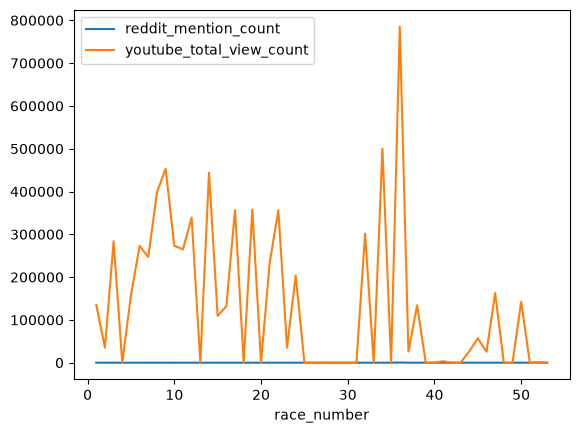

In [32]:
weekly = master_df.groupby('race_number').agg({
    'reddit_mention_count': 'sum',
    'youtube_total_view_count': 'sum'
})
weekly.plot()

In [33]:
dictionary_filled = data_dictionary.format( date=datetime.now().strftime('%Y-%m-%d'), rows=len(master_df), race_count=master_df['race_number'].nunique(), reddit_count=len(master_df[master_df['reddit_mention_count'] > 0]), youtube_count=len(master_df[master_df['youtube_total_view_count'] > 0]), news_count=len(master_df[master_df['news_total_mentions'] > 0]) )

In [34]:
with open('../docs/data_dictionary.md', 'w') as f: f.write(dictionary_filled)

print("Data dictionary saved to: docs/data_dictionary.md")

Data dictionary saved to: docs/data_dictionary.md
